# 05 - Inventory Planning & Reorder Recommendation Layer
## Smart Retail Demand Forecasting & Inventory Planner

**Objective**: Convert 16-day future product-family demand forecasts into actionable, risk-quantified inventory reorder recommendations using statistical safety stock calculations derived from model validation errors.

> **Note on Number Formatting**: This project uses the **Indian Numbering System** (Lakhs and Crores comma placement, e.g., `1,38,90,272` units) for all user-facing numerical displays, reports, and chart axis labels to enhance operational readability.

## 1. Environment Setup & Helper Functions

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

outputs_dir = "../outputs"

# Indian Number Formatting Helper Function
def format_indian(val):
    if pd.isnull(val):
        return ""
    is_negative = val < 0
    val_abs = abs(val)
    
    if isinstance(val_abs, float) and not val_abs.is_integer():
        int_part, frac_part = f"{val_abs:.2f}".split('.')
    else:
        int_part = str(int(round(val_abs)))
        frac_part = None
        
    if len(int_part) <= 3:
        res = int_part
    else:
        last3 = int_part[-3:]
        rest = int_part[:-3]
        groups = []
        while len(rest) > 2:
            groups.insert(0, rest[-2:])
            rest = rest[:-2]
        if rest:
            groups.insert(0, rest)
        res = ",".join(groups) + "," + last3
        
    if frac_part is not None:
        res = f"{res}.{frac_part}"
    if is_negative:
        res = f"-{res}"
    return res

# Load input artifacts
future_forecast = pd.read_csv(os.path.join(outputs_dir, "future_demand_forecast.csv"))
family_summary = pd.read_csv(os.path.join(outputs_dir, "family_forecast_summary.csv"))
val_preds = pd.read_csv(os.path.join(outputs_dir, "xgboost_validation_predictions.csv"))

future_forecast["date"] = pd.to_datetime(future_forecast["date"])
val_preds["date"] = pd.to_datetime(val_preds["date"])

print("Input artifacts loaded successfully.")

Input artifacts loaded successfully.


## 2. Input Data Validation Checks

In [2]:
min_date = future_forecast["date"].min().strftime('%Y-%m-%d')
max_date = future_forecast["date"].max().strftime('%Y-%m-%d')
n_dates = future_forecast["date"].nunique()
n_families = future_forecast["family"].nunique()
n_rows = len(future_forecast)
n_nulls = future_forecast["predicted_sales"].isnull().sum()
n_negatives = (future_forecast["predicted_sales"] < 0).sum()

print("=== FUTURE FORECAST INPUT VALIDATION ===")
print(f"Date Horizon (Expected 2017-08-16 to 2017-08-31) : {min_date} to {max_date}")
print(f"Unique Dates Count (Expected 16)                : {n_dates} -> {'PASSED' if n_dates == 16 else 'FAILED'}")
print(f"Product Families Count (Expected 33)            : {n_families} -> {'PASSED' if n_families == 33 else 'FAILED'}")
print(f"Total Forecast Rows (Expected 528)               : {n_rows} -> {'PASSED' if n_rows == 528 else 'FAILED'}")
print(f"Missing Values Count (Expected 0)                : {n_nulls} -> {'PASSED' if n_nulls == 0 else 'FAILED'}")
print(f"Negative Values Count (Expected 0)               : {n_negatives} -> {'PASSED' if n_negatives == 0 else 'FAILED'}")

=== FUTURE FORECAST INPUT VALIDATION ===
Date Horizon (Expected 2017-08-16 to 2017-08-31) : 2017-08-16 to 2017-08-31
Unique Dates Count (Expected 16)                : 16 -> PASSED
Product Families Count (Expected 33)            : 33 -> PASSED
Total Forecast Rows (Expected 528)               : 528 -> PASSED
Missing Values Count (Expected 0)                : 0 -> PASSED
Negative Values Count (Expected 0)               : 0 -> PASSED


## 3. Historical Validation Error Analysis & Uncertainty Estimation
Computing validation forecast errors ($e_i = y_i - \hat{y}_i$) per product family to capture family-specific demand variance and error standard deviations.

In [3]:
# Calculate validation prediction errors
val_preds["error"] = val_preds["daily_sales"] - val_preds["xgb_pred"]
overall_error_std = val_preds["error"].std(ddof=1)

# Family-level validation error standard deviation
family_error_stats = val_preds.groupby("family")["error"].agg(
    val_count="count",
    family_error_std=lambda x: x.std(ddof=1) if len(x) > 1 else np.nan
).reset_index()

# Fallback strategy: If family-level std is missing/insufficient, use overall error std
family_error_stats["validation_error_std"] = family_error_stats["family_error_std"].fillna(overall_error_std)
family_error_stats["used_fallback"] = family_error_stats["family_error_std"].isnull()

print(f"Overall Validation Error Standard Deviation: {format_indian(overall_error_std)}")
print(f"Families requiring fallback to overall error std: {family_error_stats['used_fallback'].sum()}")

# Display sample formatted table
disp_err_df = family_error_stats.head().copy()
disp_err_df["validation_error_std"] = disp_err_df["validation_error_std"].apply(format_indian)
display(disp_err_df)

Overall Validation Error Standard Deviation: 4,875.13
Families requiring fallback to overall error std: 0


,family,val_count,family_error_std,validation_error_std,used_fallback
0,AUTOMOTIVE,16,59.223825,59.22,False
1,BABY CARE,16,31.482767,31.48,False
2,BEAUTY,16,66.573465,66.57,False
3,BEVERAGES,16,12930.382033,"12,930.38",False
4,BOOKS,16,31.945512,31.95,False


## 4. Safety Stock & Recommended Inventory Calculation
Applying statistical safety stock formula for a 95% service level ($z = 1.645$) over the 16-day planning horizon:

$$\text{Safety Stock} = z \times \sigma_{\text{error}} \times \sqrt{L}$$

where $L = 16$ days (planning horizon).

In [4]:
# 16-day total expected demand per product family
family_forecast = future_forecast.groupby("family")["predicted_sales"].sum().reset_index()
family_forecast.rename(columns={"predicted_sales": "forecast_demand_16d"}, inplace=True)

# Merge error std dev stats
recs = family_forecast.merge(family_error_stats[["family", "validation_error_std", "used_fallback"]], on="family", how="left")

# Parameters
z_score = 1.645  # 95% Service Level
horizon_days = 16

# Safety Stock formula
recs["safety_stock_raw"] = z_score * recs["validation_error_std"] * np.sqrt(horizon_days)
recs["safety_stock"] = np.maximum(0, np.round(recs["safety_stock_raw"])).astype(int)

# Recommended Stock
recs["forecast_demand_16d"] = np.round(recs["forecast_demand_16d"]).astype(int)
recs["recommended_stock"] = recs["forecast_demand_16d"] + recs["safety_stock"]

# Risk Ratio and Risk Categorization
recs["risk_ratio"] = recs["safety_stock"] / np.maximum(1, recs["forecast_demand_16d"])

def categorize_risk(ratio):
    if ratio < 0.10:
        return "LOW"
    elif ratio < 0.20:
        return "MEDIUM"
    else:
        return "HIGH"

recs["risk_category"] = recs["risk_ratio"].apply(categorize_risk)

# Sort by forecast demand descending & assign demand rank
recs = recs.sort_values("forecast_demand_16d", ascending=False).reset_index(drop=True)
recs["demand_rank"] = recs.index + 1

# Format output recommendation table for numerical saving (raw)
output_cols = ["family", "forecast_demand_16d", "validation_error_std", "safety_stock", "recommended_stock", "risk_ratio", "risk_category", "demand_rank"]
recs_table = recs[output_cols]

# Format display table with Indian numbering for user display
disp_recs_table = recs_table.head(10).copy()
disp_recs_table["forecast_demand_16d"] = disp_recs_table["forecast_demand_16d"].apply(format_indian)
disp_recs_table["validation_error_std"] = disp_recs_table["validation_error_std"].apply(format_indian)
disp_recs_table["safety_stock"] = disp_recs_table["safety_stock"].apply(format_indian)
disp_recs_table["recommended_stock"] = disp_recs_table["recommended_stock"].apply(format_indian)
disp_recs_table["risk_ratio"] = disp_recs_table["risk_ratio"].apply(lambda x: f"{x*100:.2f}%")

display(disp_recs_table)

,family,forecast_demand_16d,validation_error_std,safety_stock,recommended_stock,risk_ratio,risk_category,demand_rank
0,GROCERY I,"38,13,689","17,666.17","1,16,243","39,29,932",3.05%,LOW,1
1,BEVERAGES,"28,85,107","12,930.38","85,082","29,70,189",2.95%,LOW,2
2,PRODUCE,"19,15,558","5,493.74","36,149","19,51,707",1.89%,LOW,3
3,CLEANING,"10,20,012","9,067.23","59,662","10,79,674",5.85%,LOW,4
4,DAIRY,"7,05,612","1,966.20","12,938","7,18,550",1.83%,LOW,5
5,LAWN AND GARDEN,"6,26,570",177.25,"1,166","6,27,736",0.19%,LOW,6
6,SCHOOL AND OFFICE SUPPLIES,"5,13,943","2,305.80","15,172","5,29,115",2.95%,LOW,7
7,BREAD/BAKERY,"4,54,181","1,821.22","11,984","4,66,165",2.64%,LOW,8
8,MEATS,"3,08,084","1,442.01","9,488","3,17,572",3.08%,LOW,9
9,POULTRY,"3,07,791","1,666.87","10,968","3,18,759",3.56%,LOW,10


## 5. Summary Tables & Output Exports

In [5]:
# Create Inventory Planning Summary Table
tot_dem = int(recs_table["forecast_demand_16d"].sum())
tot_ss = int(recs_table["safety_stock"].sum())
tot_rec = int(recs_table["recommended_stock"].sum())

inventory_summary = {
    "total_forecast_demand": tot_dem,
    "total_safety_stock": tot_ss,
    "total_recommended_inventory": tot_rec,
    "num_low_risk": int((recs_table["risk_category"] == "LOW").sum()),
    "num_medium_risk": int((recs_table["risk_category"] == "MEDIUM").sum()),
    "num_high_risk": int((recs_table["risk_category"] == "HIGH").sum())
}

summary_df = pd.DataFrame([inventory_summary])

# User-facing formatted display summary
disp_summary = summary_df.copy()
disp_summary["total_forecast_demand"] = disp_summary["total_forecast_demand"].apply(format_indian)
disp_summary["total_safety_stock"] = disp_summary["total_safety_stock"].apply(format_indian)
disp_summary["total_recommended_inventory"] = disp_summary["total_recommended_inventory"].apply(format_indian)
display(disp_summary)

print(f"Total Forecast Demand       : {format_indian(tot_dem)} units")
print(f"Total Safety Stock Buffer   : {format_indian(tot_ss)} units")
print(f"Total Recommended Inventory : {format_indian(tot_rec)} units")

# Save output files
recs_table.to_csv(os.path.join(outputs_dir, "inventory_recommendations.csv"), index=False)
summary_df.to_csv(os.path.join(outputs_dir, "inventory_summary.csv"), index=False)
print(f"Saved 'outputs/inventory_recommendations.csv' and 'outputs/inventory_summary.csv'.")

,total_forecast_demand,total_safety_stock,total_recommended_inventory,num_low_risk,num_medium_risk,num_high_risk
0,"1,38,90,272","4,13,159","1,43,03,431",28,1,4


Total Forecast Demand       : 1,38,90,272 units
Total Safety Stock Buffer   : 4,13,159 units
Total Recommended Inventory : 1,43,03,431 units
Saved 'outputs/inventory_recommendations.csv' and 'outputs/inventory_summary.csv'.


## 6. Visualizations (with Indian Number System Axis Formatting)
1. **Top 10 Product Families**: 16-Day Forecast Demand vs Recommended Inventory (y-axis formatted using Indian numbering `5,00,000`, `10,00,000`, `15,00,000`).
2. **Inventory Risk Profile**: Risk Ratio vs Forecast Demand grouped by Risk Category (x-axis tick labels formatted using Indian numbering).

### 6.1 Top 10 Product Families: Demand vs Recommended Inventory

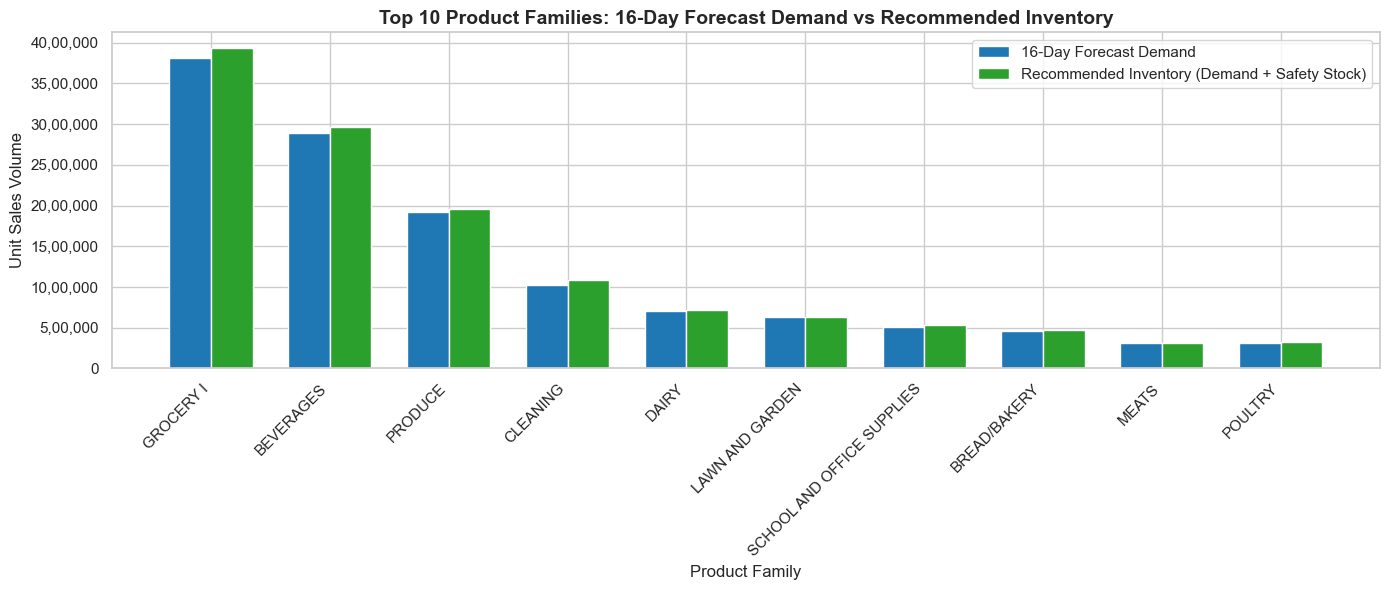

In [6]:
top10 = recs_table.head(10).copy()

fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.35
x = np.arange(len(top10))

ax.bar(x - bar_width/2, top10["forecast_demand_16d"], width=bar_width, label="16-Day Forecast Demand", color="#1f77b4")
ax.bar(x + bar_width/2, top10["recommended_stock"], width=bar_width, label="Recommended Inventory (Demand + Safety Stock)", color="#2ca02c")

ax.set_title("Top 10 Product Families: 16-Day Forecast Demand vs Recommended Inventory", fontsize=14, fontweight="bold")
ax.set_xlabel("Product Family", fontsize=12)
ax.set_ylabel("Unit Sales Volume", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(top10["family"], rotation=45, ha="right")

# Apply Indian Numbering System Formatter to Y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: format_indian(y)))

plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "inventory_recommendations.png"), dpi=300)
plt.show()

### 6.2 Inventory Risk Profile

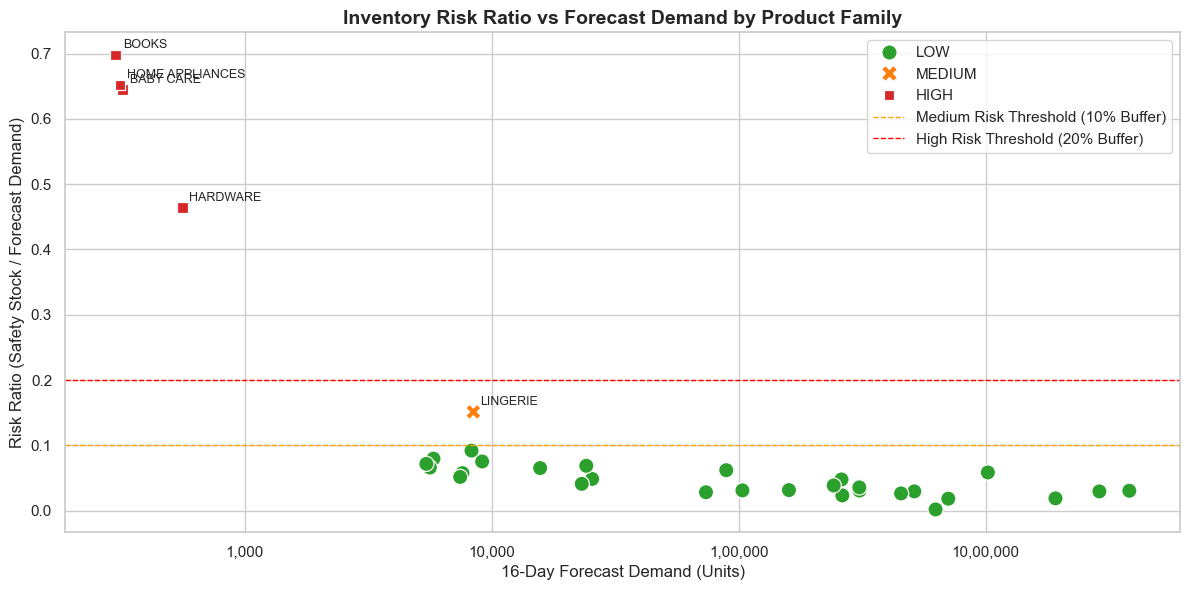

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
palette = {"LOW": "#2ca02c", "MEDIUM": "#ff7f0e", "HIGH": "#d62728"}
sns.scatterplot(data=recs_table, x="forecast_demand_16d", y="risk_ratio", hue="risk_category", palette=palette, s=120, style="risk_category", ax=ax)

# Annotate non-low risk families
for idx, row in recs_table.iterrows():
    if row["risk_category"] in ["HIGH", "MEDIUM"]:
        ax.annotate(row["family"], (row["forecast_demand_16d"], row["risk_ratio"]),
                    textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

ax.axhline(0.10, color="orange", linestyle="--", linewidth=1, label="Medium Risk Threshold (10% Buffer)")
ax.axhline(0.20, color="red", linestyle="--", linewidth=1, label="High Risk Threshold (20% Buffer)")

ax.set_title("Inventory Risk Ratio vs Forecast Demand by Product Family", fontsize=14, fontweight="bold")
ax.set_xlabel("16-Day Forecast Demand (Units)", fontsize=12)
ax.set_ylabel("Risk Ratio (Safety Stock / Forecast Demand)", fontsize=12)
ax.set_xscale("log")

# Apply Indian Numbering System Formatter to X-axis
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x_val, pos: format_indian(x_val)))

plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "inventory_risk.png"), dpi=300)
plt.show()

## 7. Comprehensive Final Validation Checks

In [8]:
v_families = len(recs_table) == 33
v_unique = recs_table["family"].nunique() == 33
v_nulls = recs_table.isnull().sum().sum() == 0
v_neg_ss = (recs_table["safety_stock"] < 0).sum() == 0
v_neg_rec = (recs_table["recommended_stock"] < 0).sum() == 0
v_rec_ge_dem = (recs_table["recommended_stock"] >= recs_table["forecast_demand_16d"]).all()
v_tot_ge_dem = recs_table["recommended_stock"].sum() >= recs_table["forecast_demand_16d"].sum()

print("=== COMPREHENSIVE INVENTORY LAYER VALIDATION CHECKS ===")
print(f"1. Exactly 33 product families              : {'PASSED' if v_families else 'FAILED'}")
print(f"2. Exactly 1 recommendation per family     : {'PASSED' if v_unique else 'FAILED'}")
print(f"3. Zero NaN values in table                 : {'PASSED' if v_nulls else 'FAILED'}")
print(f"4. Zero negative safety stock values        : {'PASSED' if v_neg_ss else 'FAILED'}")
print(f"5. Zero negative recommended inventory      : {'PASSED' if v_neg_rec else 'FAILED'}")
print(f"6. recommended_stock >= forecast_demand_16d : {'PASSED' if v_rec_ge_dem else 'FAILED'}")
print(f"7. total_recommended >= total_forecast     : {'PASSED' if v_tot_ge_dem else 'FAILED'}")

=== COMPREHENSIVE INVENTORY LAYER VALIDATION CHECKS ===
1. Exactly 33 product families              : PASSED
2. Exactly 1 recommendation per family     : PASSED
3. Zero NaN values in table                 : PASSED
4. Zero negative safety stock values        : PASSED
5. Zero negative recommended inventory      : PASSED
6. recommended_stock >= forecast_demand_16d : PASSED
7. total_recommended >= total_forecast     : PASSED


## Inventory Planning Concepts & Methodology

### 1. Why Demand Forecasting Alone is Not Enough for a Retailer
A point forecast (e.g. predicting exactly 100 units of Grocery sales tomorrow) represents the **expected mean** of future demand. However, real-world retail demand fluctuates due to weather, local promotions, supply chain delays, and random consumer behavior.

If a retailer stocks *only* the point forecast demand:
- Any upside demand fluctuation immediately results in **stockouts**, lost sales revenue, and disappointed customers.
- Holding zero buffer leaves the supply chain vulnerable to lead-time delays.

An operational inventory system must complement point forecasts with **statistical safety stock**.

### 2. What is Safety Stock?
Safety stock is a calculated buffer inventory held to protect against demand volatility and forecast error during the replenishment lead time. It acts as insurance against out-of-stock events.

### 3. Why Validation Errors Estimate Uncertainty
Rather than applying an arbitrary rule of thumb (e.g. adding a flat 10% to all items), we derive uncertainty empirical estimates from the model's **historical validation forecast errors** ($\sigma_{\text{error}}$).
- Highly predictable categories (e.g. `PRODUCE`, `BREAD/BAKERY`) have smaller forecast errors and require smaller safety buffers.
- Highly volatile categories (e.g. `SCHOOL AND OFFICE SUPPLIES`, `GROCERY I`) have larger forecast errors and automatically receive higher safety buffers.

### 4. Why 95% Service Level $z = 1.645$?
Under the standard normal distribution assumption of forecast errors, the $z$-score represents the number of standard deviations required to satisfy customer demand a specific percentage of the time:
- A **95% Service Level** means the store aims to fulfill customer demand without stockouts in 95 out of 100 replenishment cycles.
- The standard normal inverse cumulative distribution function yields $z = 1.645$ for 95% coverage.

### 5. Why Safety Stock Scales with $\sqrt{\text{Planning Horizon}}$?
In time-series probability theory, variance accumulates additively over independent consecutive days ($Var(L) = L \cdot \sigma^2$).
Taking the standard deviation of cumulative demand across an $L=16$ day planning horizon yields:

$$\sigma_{16\text{-day}} = \sqrt{16 \cdot \sigma^2} = \sqrt{16} \times \sigma = 4 \times \sigma$$

Thus, safety stock scales linearly with $\sqrt{L}$ rather than $L$, preventing massive overstocking for longer planning windows.

### 6. Planning Recommendation vs Stockout Guarantee
Safety stock calculations provide a **risk-quantified recommendation** based on historical error distributions. They do not guarantee 100% stockout elimination, as extreme black-swan events (e.g. natural disasters or unexpected supply chain failures) exceed 95% statistical confidence bounds.